## Logistic Regression (Binary Classification)

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn import functional as F
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.linear_model import LogisticRegression

In [39]:
def get_path(filename="Xtr"):
    return f"../data/processed/{filename}.csv"

def get_data(data="Xtr"):
    return torch.from_numpy(pd.read_csv(get_path(data)).values).clone().detach().to(torch.float32)

Xtr = get_data("Xtr"); ytr = get_data("ytr")
Xdev = get_data("Xdev"); ydev = get_data("ydev")
Xte = get_data("Xte"); yte = get_data("yte")


In [40]:
Xtr.shape, ytr.shape, Xdev.shape, ydev.shape, Xte.shape, yte.shape

(torch.Size([31647, 18]),
 torch.Size([31647, 1]),
 torch.Size([6782, 18]),
 torch.Size([6782, 1]),
 torch.Size([6782, 18]),
 torch.Size([6782, 1]))

In [47]:
fan_in = Xtr.shape[-1]
fan_out = 1

w = torch.randn(fan_in, fan_out) / fan_in**0.5; w.requires_grad=True
b = torch.randn(fan_out) * 0.01; b.requires_grad=True

lossi = []
train_acci = []
val_acci = []
lr = 0.01
epochs = 100000
# optimizer = torch.optim.SGD((w, b), lr, momentum=0.8, maximize=False, weight_decay=1e-4)
optimizer = torch.optim.Adam((w, b), lr, weight_decay=1e-4)

In [48]:
for i in range(epochs):

    n_pos = ytr.sum()
    n_neg = (ytr == 0).sum()
    pos_weight = n_neg / n_pos


    logits = Xtr @ w + b
    loss = F.binary_cross_entropy_with_logits(logits, ytr, pos_weight=pos_weight)

    optimizer.zero_grad()
    loss.backward()

    optimizer.step()
    # Track
    with torch.no_grad():
        train_acc = ((logits >= 0).float() == ytr).float().mean()
        val_logits = Xdev @ w + b
        val_acc = ((val_logits >= 0).float() == ydev).float().mean()

    lossi.append(loss.item())
    train_acci.append(train_acc)
    val_acci.append(val_acc)
    if i%(epochs/10) == 0:
        print(f"{i/(epochs/10)}: Loss {loss.item():.5f} train_acc {train_acc:.5f} val_acc {val_acc:.5f}")

0.0: Loss 3.71493 train_acc 0.11698 val_acc 0.11693
1.0: Loss 1.10437 train_acc 0.65131 val_acc 0.65128
2.0: Loss 1.10437 train_acc 0.65131 val_acc 0.65128
3.0: Loss 1.10437 train_acc 0.65131 val_acc 0.65128


KeyboardInterrupt: 

In [51]:
import numpy as np
# Threshold tuning
thresholds = torch.arange(0.05, 0.95, 0.01)
scores = [f1_score(ydev, val_logits >= t) for t in thresholds]
best_t = thresholds[np.argmax(scores)]

In [52]:
preds = (val_logits >= best_t).float()
print("Mine Logistic Regression")
print("Precision:", precision_score(ydev, preds))
print("Recall:", recall_score(ydev, preds))
print("F1:", f1_score(ydev, preds))
print("AUC:", roc_auc_score(ydev, torch.sigmoid(val_logits).detach()))

Mine Logistic Regression
Precision: 0.36633663366336633
Recall: 0.3266078184110971
F1: 0.3453333333333333
AUC: 0.70036481342318


In [ ]:
# first result
# Loss: 7.46 -> 0.33117
# Acc: 0.88293
    
# better initialization (* 0.01) of weights
# Loss: 0.66 -> 0.33117
# Acc: 0.88293

# Xavier inititalization of weights
# Loss: 12.59469 -> 0.33117
# Acc:  0.88293

# + L2 
# Loss: 0.52322 -> 0.33117
# Acc:  0.88307

# Adam Optimizer
# Loss: 0.74816  -> 0.33117
# Acc:  0.88307

# panalty for class imbalanced
# Loss: 1.11233
# Recall: 0.682219419924338, Precision: 0.20037037037037037, f1: 0.3097623819066705

# after threshold tuning (best threshold -> 0.500)
# f1: 0.3465940054495913

In [123]:
print((ytr == 0).float().mean())  # if this is ~0.883, your model may be doing nothing useful

tensor(0.8830)


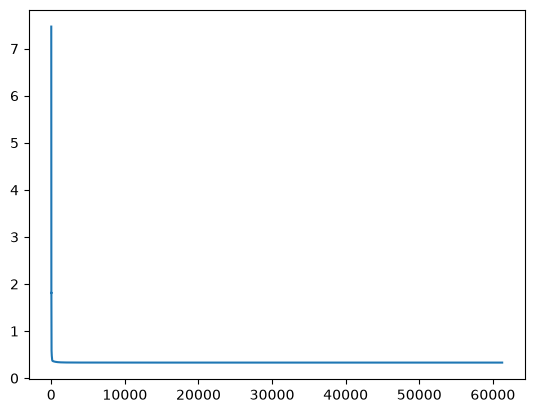

In [111]:
plt.plot(lossi)

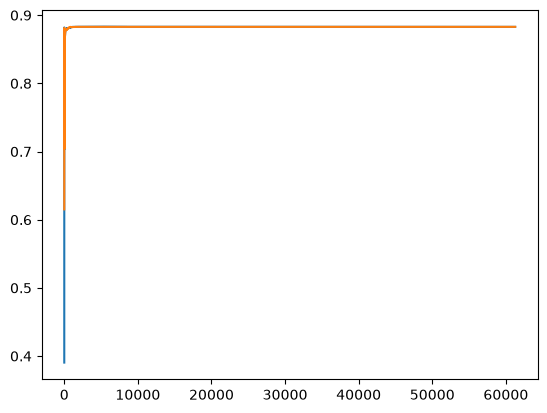

In [112]:
plt.plot(train_acci)
plt.plot(val_acci)